In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib_venn import venn3, venn3_circles 

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Synergy vs. Baseline Analysis (Volcano Plots)

- A side-by-side or multi-panel Volcano Plot comparing shPR_knockdown_effect_in_WT against shPR_knockdown_effect_in_Y537S_mutant
- Highlight genes that are heavily suppressed by the knockdown in mutant cells but remain untouched in wild-type cells. This identifies mutant-specific therapeutic targets (genes that the mutation makes the cell dependent upon).

In [3]:
from plotting_modules.volcano_plots import (
    prep_volcano_df, 
    classify_volcano
)

In [4]:
def plot_two_panel_volcano(
    left_csv,
    right_csv,
    left_title="shPR knockdown effect in WT",
    right_title="shPR knockdown effect in Y537S mutant",
    log2fc_col="log2FoldChange",
    padj_col="padj",
    padj_threshold=0.05,
    log2fc_threshold=1.0,
    figsize=(14, 6),
    point_size=12,
):
    left = prep_volcano_df(left_csv, log2fc_col=log2fc_col, padj_col=padj_col)
    right = prep_volcano_df(right_csv, log2fc_col=log2fc_col, padj_col=padj_col)

    l_ns, l_up, l_down = classify_volcano(
        left, log2fc_col=log2fc_col, padj_col=padj_col,
        padj_threshold=padj_threshold, log2fc_threshold=log2fc_threshold
    )
    r_ns, r_up, r_down = classify_volcano(
        right, log2fc_col=log2fc_col, padj_col=padj_col,
        padj_threshold=padj_threshold, log2fc_threshold=log2fc_threshold
    )

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    def draw_panel(ax, df, ns, up, down, title):
        ax.scatter(df.loc[ns, log2fc_col], df.loc[ns, "minus_log10_padj"],
                   s=point_size, c="#B8B8B8", alpha=0.6, linewidths=0, label="Not significant")
        ax.scatter(df.loc[down, log2fc_col], df.loc[down, "minus_log10_padj"],
                   s=point_size, c="#4C78A8", alpha=0.8, linewidths=0, label="Down")
        ax.scatter(df.loc[up, log2fc_col], df.loc[up, "minus_log10_padj"],
                   s=point_size, c="#D62728", alpha=0.8, linewidths=0, label="Up")

        ax.axvline(-log2fc_threshold, color="black", linestyle="--", linewidth=1)
        ax.axvline(log2fc_threshold, color="black", linestyle="--", linewidth=1)
        ax.axhline(-np.log10(padj_threshold), color="black", linestyle="--", linewidth=1)

        ax.set_title(title)
        ax.set_xlabel("log2 fold change")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    draw_panel(axes[0], left, l_ns, l_up, l_down, left_title)
    draw_panel(axes[1], right, r_ns, r_up, r_down, right_title)

    axes[0].set_ylabel("-log10 adjusted p-value")
    axes[1].legend(frameon=False, loc="upper right")

    fig.suptitle("Synergy vs. Baseline: shPR Knockdown Effects", y=1.02)
    fig.tight_layout()
    #plt.show()

    return fig

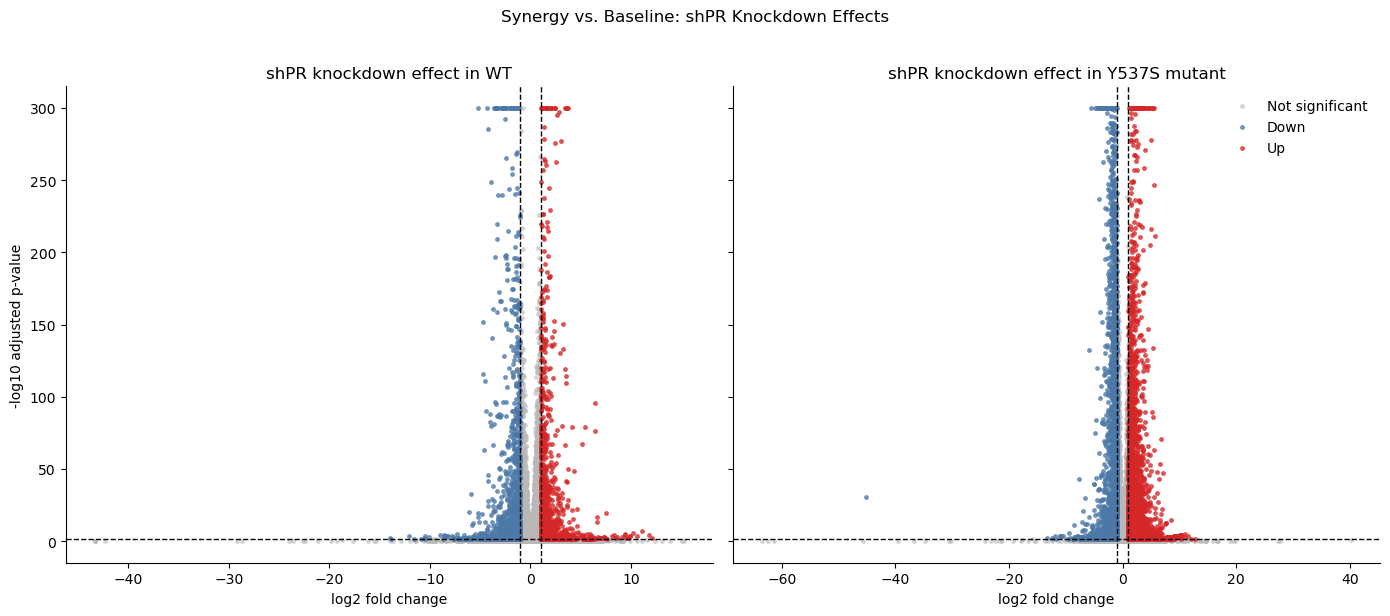

In [5]:
plot_two_panel_volcano(
    left_csv="./deseq2_fit/deseq2_results/WT_shPR_vs_shGFP.csv",
    right_csv="./deseq2_fit/deseq2_results/mutant_shPR_vs_shGFP.csv",
    padj_threshold=0.05,
    log2fc_threshold=1.0,
)
plt.show()

#### Highlight genes that are heavily suppressed by the knockdown but not in WT

In [6]:
from plotting_modules.flag_genes import (
    load_deseq_table,
    merge_wt_mutant_tables,
    add_mutant_specific_flag,
    plot_mutant_volcano_with_highlights,
    save_candidate_table
)

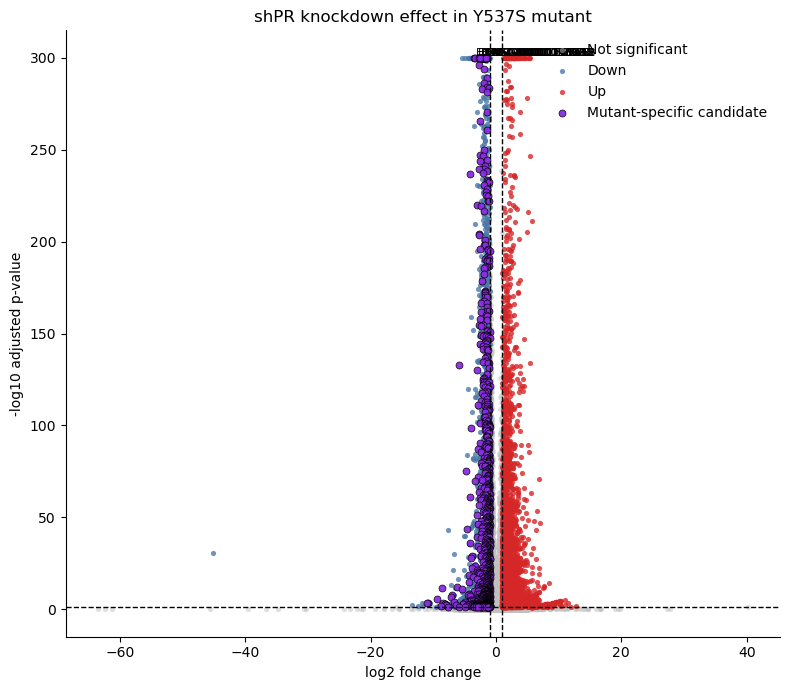

PosixPath('plots/mutant_specific_volcano.png')

In [7]:
merged = merge_wt_mutant_tables(
    wt_csv="./deseq2_fit/deseq2_results/WT_shPR_vs_shGFP.csv",
    mutant_csv="./deseq2_fit/deseq2_results/mutant_shPR_vs_shGFP.csv",
)

merged = add_mutant_specific_flag(
    merged,
    padj_threshold=0.05,
    log2fc_threshold=1.0,
    wt_effect_threshold=0.5,
)

save_candidate_table(
    merged,
    out_csv="plots/mutant_specific_candidates.csv",
)

plot_mutant_volcano_with_highlights(
    merged,
    out_png="plots/mutant_specific_volcano.png",
    label_top_n=10,
)

### Interaction volcano plot: show the actual mutant-vs-WT difference in response.

In [8]:
df = pd.read_csv("./deseq2_fit/deseq2_results/interaction.csv", index_col=0)
df.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,direction
gene_id,,,,,,,,
ENSG00000139998,6037.719954,2.383693,0.054139,44.029086,0.0,0.0,True,up
ENSG00000070495,5060.369649,-3.517828,0.073062,-48.148496,0.0,0.0,True,down
ENSG00000106541,17328.158766,3.055250,0.069070,44.234078,0.0,0.0,True,up
ENSG00000302734,5364.909356,4.596873,0.061748,74.445291,0.0,0.0,True,up
ENSG00000120053,12625.399537,-2.584717,0.053643,-48.183627,0.0,0.0,True,down


In [9]:
from plotting_modules.basic_volcano import plot_volcano

[plot_volcano] WARNING: no label column found (tried 'symbol' and ['symbol', 'gene_symbol', 'Gene', 'gene_name', 'GeneSymbol', 'external_gene_name', 'hgnc_symbol', 'Symbol', 'gene']). No gene labels will be drawn. Available columns: ['baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj', 'significant', 'direction', 'padj_plot', 'neg_log10_padj', 'log2fc_plot', 'is_clipped']. Pass label_col='<your column>' explicitly to fix this.


<Axes: title={'center': 'Volcano Plot of Interaction Contrast'}, xlabel='log$_2$ Fold Change', ylabel='-log$_{10}$ Adjusted P-value'>

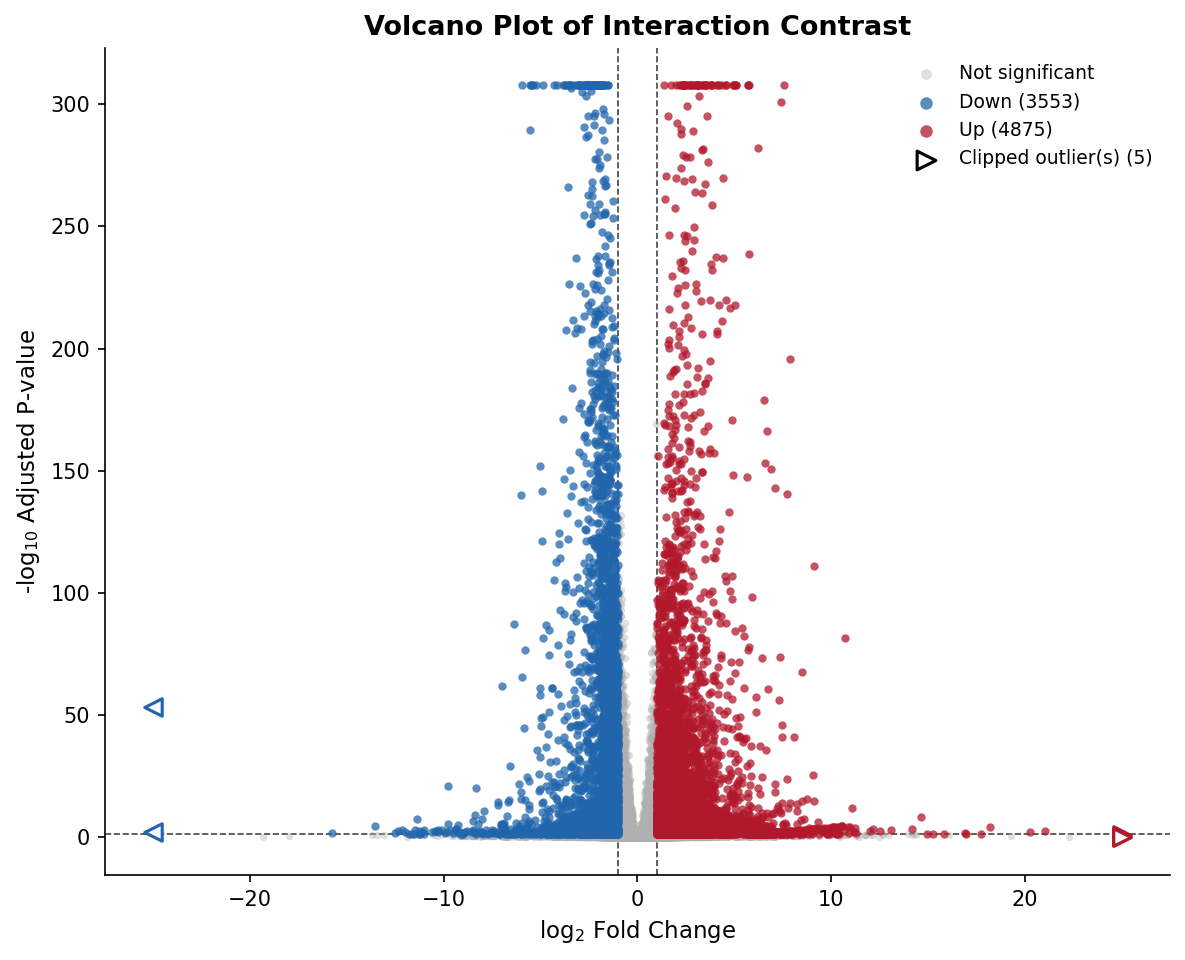

In [10]:
plot_volcano(res_df = df, clip_log2fc =[-25, 25], title ="Volcano Plot of Interaction Contrast")

## Expression Heatmap of Interaction Contrast by padj

In [11]:
# filter top 50 genes based on adjusted p-value for plotting
top_50_genes = df.sort_values(by='padj').head(50).index.tolist()

In [12]:
# load the gene-level read counts matrix
counts_df = pd.read_csv("./gene-counts/gene_level_counts.csv", index_col=0)

# Re-apply filter to clear out unexpressed genes
# Keeps genes with at least 10 reads total across all 10 samples combined
counts_filtered = counts_df[counts_df.sum(axis=1) >= 10].copy()

# Apply the standard log2 transformation to stabilize variance across the genome
# add a pseudo-count of +1 so that log2(0) does not break the math

df_expression_matrix = np.log10(counts_filtered + 1) # or np.log2 depending on EDA setup

print(f"Read count matrix shape: {df_expression_matrix.shape} (Genes x Samples)")

Read count matrix shape: (37205, 11) (Genes x Samples)


In [13]:
# plot heatmap of top 50 significant genes
# Since df_expression_matrix has genes as rows, slice directly
heatmap_data = df_expression_matrix.loc[top_50_genes]

#Optional Z-score normalization across rows (genes)
# This scales each gene's row relative to itself, making expression shifts easy to see

heatmap_scaled = heatmap_data.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

#Define color labels for the sample columns to track the 4 experimental groups
sample_groups = {
    'SRR36108974': '#e41a1c', 'SRR36108976': '#e41a1c',  # Y537S_shGFP (Red Mutant Control)
    'SRR36108971': '#984ea3', 'SRR36108972': '#984ea3', 'SRR36108973': '#984ea3',  # Y537S_shPR (Purple Double Mutant)
    'SRR36108977': '#377eb8', 'SRR36108978': '#377eb8', 'SRR36108979': '#377eb8',  # WT_shPR (Blue)
    'SRR36108980': '#4daf4a', 'SRR36108981': '#4daf4a', 'SRR36108982': '#4daf4a'   # WT_shGFP (Green WT Control)
}
col_colors = pd.Series(heatmap_scaled.columns).map(sample_groups).values

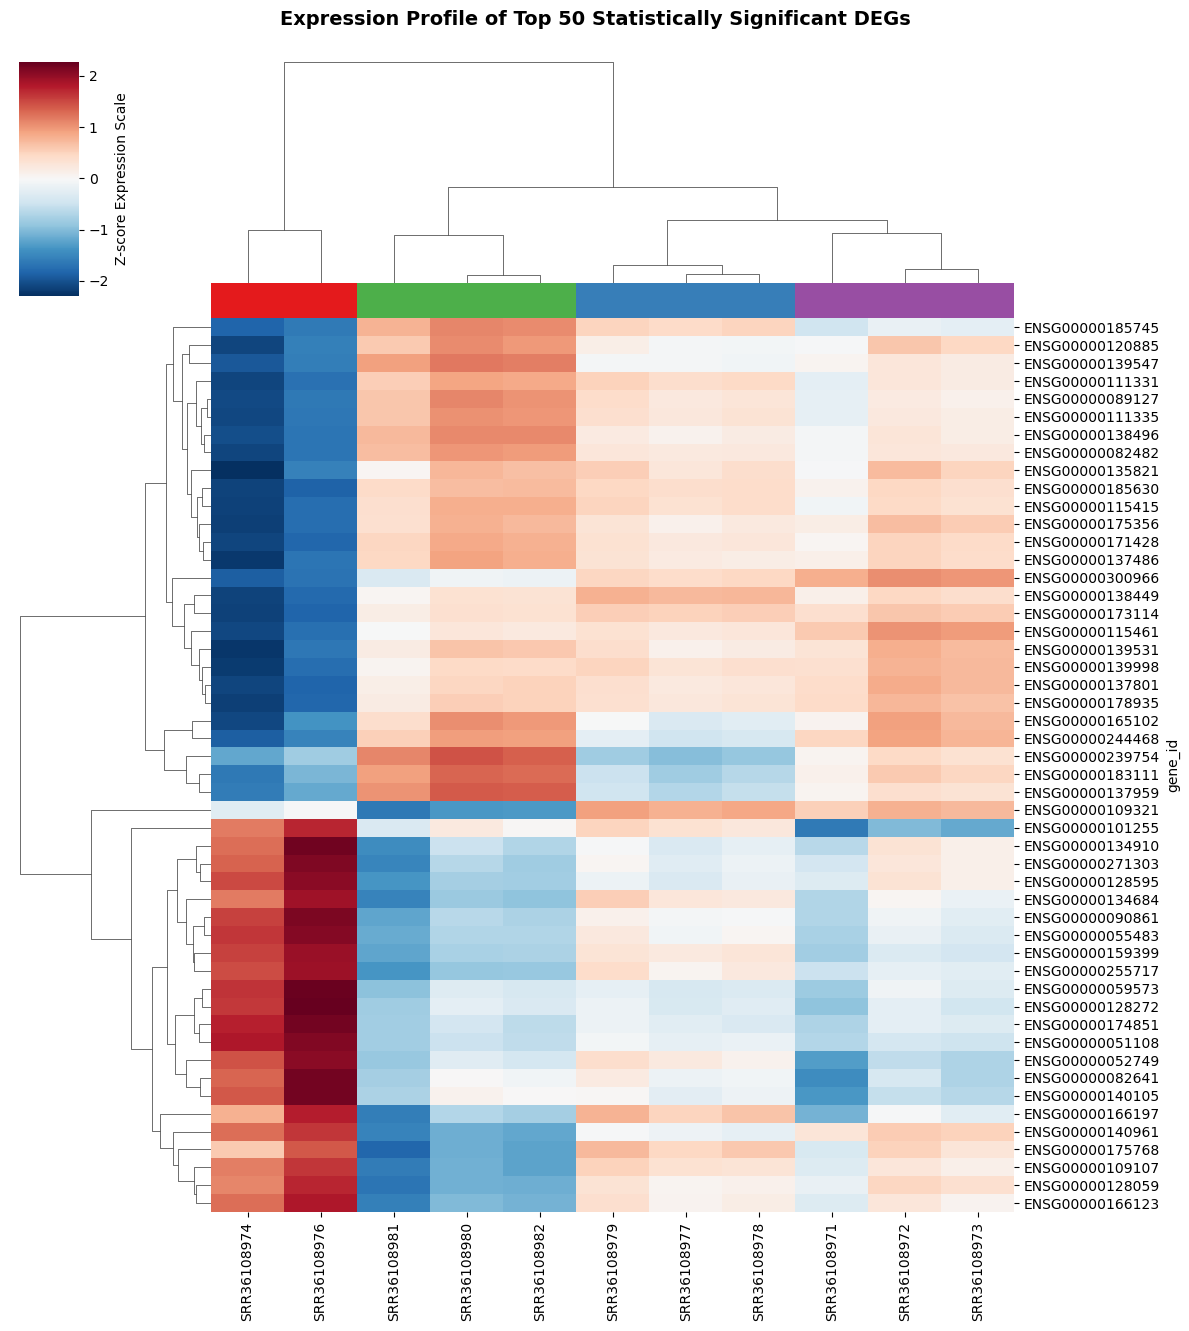

In [14]:
# Generate the Hierarchical Clustermap
g = sns.clustermap(
    heatmap_scaled,
    method='average',
    metric='euclidean',
    cmap='RdBu_r',          # Red = Up-regulated, Blue = Down-regulated
    col_colors=col_colors,  # Track bar at the top mapping samples to groups
    figsize=(12, 13),
    yticklabels=True,      # Turn to True if you want to see the specific Gene IDs on rows
    xticklabels=True,
    cbar_kws={'label': 'Z-score Expression Scale'}
)

g.fig.suptitle('Expression Profile of Top 50 Statistically Significant DEGs', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Insights:

- The top and bottom blocks of the heatmap have two diametrically opposed states of the cell:

    - **Red block (Y537S_shGFP):** Hyper-activated Mutant Estrogen Receptor, and full Progesterone Receptor.
    - **Green block (WT_shGFP):** Normal Estrogen Receptor, full Progesterone Receptor.
    - **Blue block (WT_shPR):** Normal Estrogen Receptor, but no Progesterone Receptor.
    - **Purple block (Y537S_shPR):** Hyper-activated Mutant Estrogen Receptor, but no Progesterone Receptor.



### 1. The Top Block: The PR-Repressed 

- This cluster of genes are deep blue on the left (Y537S_shGFP) and light red/white on the rest of the samples.

**Why?**

- **The Mutant (74, 76):** The Progesterone Receptor (PR) acts as a transcription repressor for these genes. In mutant cells treated with control shGFP, PR is fully present and actively preventing their expression.

- When PR is knocked down in the mutant background **(71, 72, 73)**, the expression profile of these genes is similar to that of WT cells. 

- This implies that the Y537S mutation cannot overcome the repressive power of an active Progesterone Receptor for this block of genes.


### 2. The Bottom Block: The Mutant-Driven / PR-Dependent 

- In the bottom cluster of the heatmap, the pattern completely reverses to a deep red on the left (Y537S_shGFP) and  light blue/red or white on the rest of the samples.

- **The Mutant (74, 76):** These genes represent the core "Aggressive Cancer Program" turned on by the constitutive Y537S Estrogen Receptor mutation. They are being hyper-activated to drive cell proliferation and tumor growth.
- In **WT shGFP (80, 81, 82)**, these genes are blue; meaning they are probably turned on exclusively by the ESR1 mutation. 
- **The WT (77, 78, 79) and Y537S (71, 72, 73) PR knockdown:** These genes remain at a baseline quiet state. 


### The "Rescue"  

- **Samples 71, 72, 73 (Y537S_shPR):** When PR is knocked down in the ER mutant cells, these genes turn from dark red (in 74, 76) to light blue/white. This implies that knocking down PR successfully forces the hyper-activated mutant cancer genes (bottom block) to cool down and match the wild-type signature. 

- Because PR knockdown rescues the lower block of genes to baseline levels, it suggests that these genes require both ESR1 mutation plus PR to be activated. 

## Ecpression Heatmap of Top Interaction Sign Genes based on Magnitude

To capture the most dramatic biological shifts, specifically the top 30 most upregulated genes and the bottom 30 most downregulated genes in the interaction contrast.

In [15]:
deg_df = pd.read_csv("./deseq2_fit/deseq2_results/interaction.significant.csv", index_col=0)
deg_df.head(2)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,direction
gene_id,,,,,,,,
ENSG00000139998,6037.719954,2.383693,0.054139,44.029086,0.0,0.0,True,up
ENSG00000070495,5060.369649,-3.517828,0.073062,-48.148496,0.0,0.0,True,down


In [16]:
sorted_deg_df = deg_df.sort_values(by = ['log2FoldChange'], ascending=False)
sorted_deg_df.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,direction
gene_id,,,,,,,,
ENSG00000206282,512.145331,21.049838,6.298945,3.341804,0.000832,0.002011,True,up
ENSG00000283918,199.794187,20.254809,6.566246,3.084686,0.002038,0.004690,True,up
ENSG00000230669,401.940329,18.229968,4.296940,4.242547,0.000022,0.000063,True,up
ENSG00000288512,53.092569,17.735302,7.205048,2.461510,0.013835,0.027923,True,up
ENSG00000203618,42.640183,16.955752,6.960411,2.436028,0.014850,0.029807,True,up


In [17]:
# Filter out statistically insignificant genes just incase
#sig_only_df = deg_df[deg_df['padj'] < 0.05]

# Sort the significant genes by log2FoldChange in descending order
# Highly positive (upregulated) will be at the top, highly negative (downregulated) at the bottom
sorted_by_fc = deg_df.sort_values(by='log2FoldChange', ascending=False)

# Extract the top 30 upregulated genes (Head)
top_30_up = sorted_by_fc.head(30).index.tolist()

# Extract the bottom 30 downregulated genes (Tail)
top_30_down = sorted_by_fc.tail(30).index.tolist()

# Combine both lists into a final 60-gene signature matrix list
top_60_magnitude_genes = top_30_up + top_30_down

In [18]:
heatmap_data = df_expression_matrix.loc[top_60_magnitude_genes]

#Optional Z-score normalization across rows (genes)
# This scales each gene's row relative to itself, making expression shifts easy to see

heatmap_scaled = heatmap_data.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# add labeling
sample_groups = {
    'SRR36108974': '#e41a1c', 'SRR36108976': '#e41a1c',  # Y537S_shGFP (Red Mutant Control)
    'SRR36108971': '#984ea3', 'SRR36108972': '#984ea3', 'SRR36108973': '#984ea3',  # Y537S_shPR (Purple Double Mutant)
    'SRR36108977': '#377eb8', 'SRR36108978': '#377eb8', 'SRR36108979': '#377eb8',  # WT_shPR (Blue)
    'SRR36108980': '#4daf4a', 'SRR36108981': '#4daf4a', 'SRR36108982': '#4daf4a'   # WT_shGFP (Green WT Control)
}

col_colors = pd.Series(heatmap_scaled.columns).map(sample_groups).values


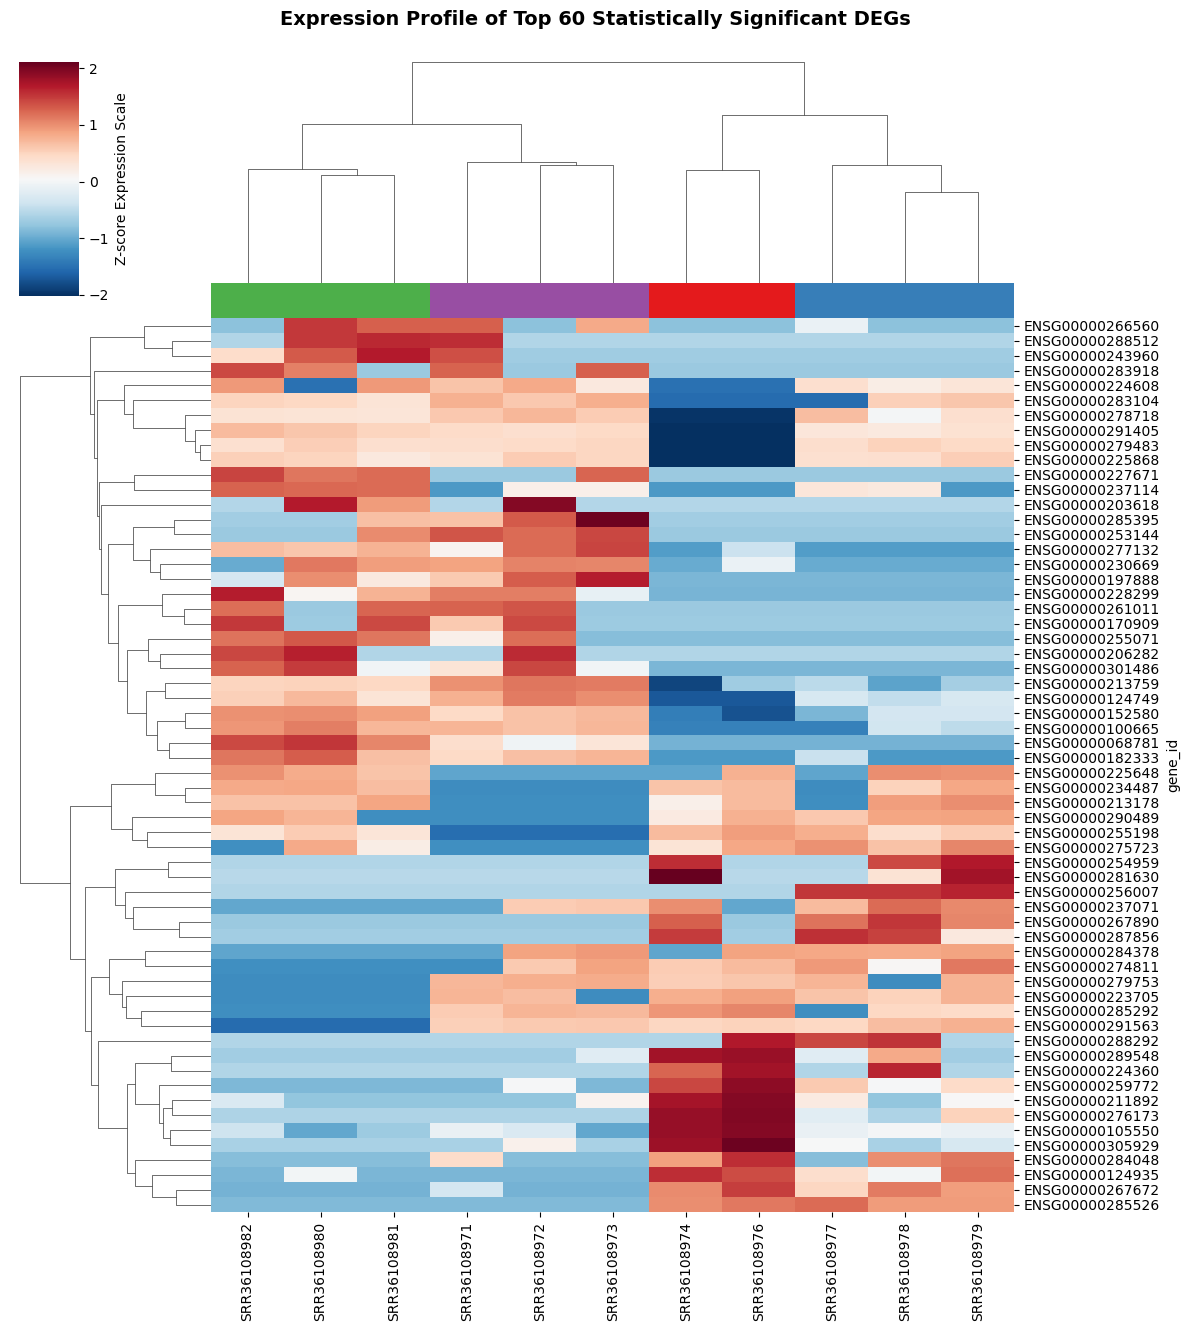

In [19]:
# plot heatmap of top 50 significant genes
# Generate the Hierarchical Clustermap
g = sns.clustermap(
    heatmap_scaled,
    method='average',
    metric='euclidean',
    cmap='RdBu_r',          # Red = Up-regulated, Blue = Down-regulated
    col_colors=col_colors,  # Track bar at the top mapping samples to groups
    figsize=(12, 13),
    yticklabels=True,      # Turn to True if you want to see the specific Gene IDs on rows
    xticklabels=True,
    cbar_kws={'label': 'Z-score Expression Scale'}
)

g.fig.suptitle('Expression Profile of Top 60 Statistically Significant DEGs', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Four-Quadrant Scatter Plot

In [20]:
from plotting_modules.quadrant_scatter import plot_quadrant_scatter

### Does PR knockdown act differently in mutant cells than in WT cells?

In [21]:
df1 = pd.read_csv("./deseq2_fit/deseq2_results/mutant_vs_WT_shGFP.significant.csv", index_col= 'gene_id')
df2 = pd.read_csv("./deseq2_fit/deseq2_results/mutant_vs_WT_shPR.significant.csv", index_col= 'gene_id')

print(df1.shape)
print(df2.shape)

(9490, 8)
(2282, 8)


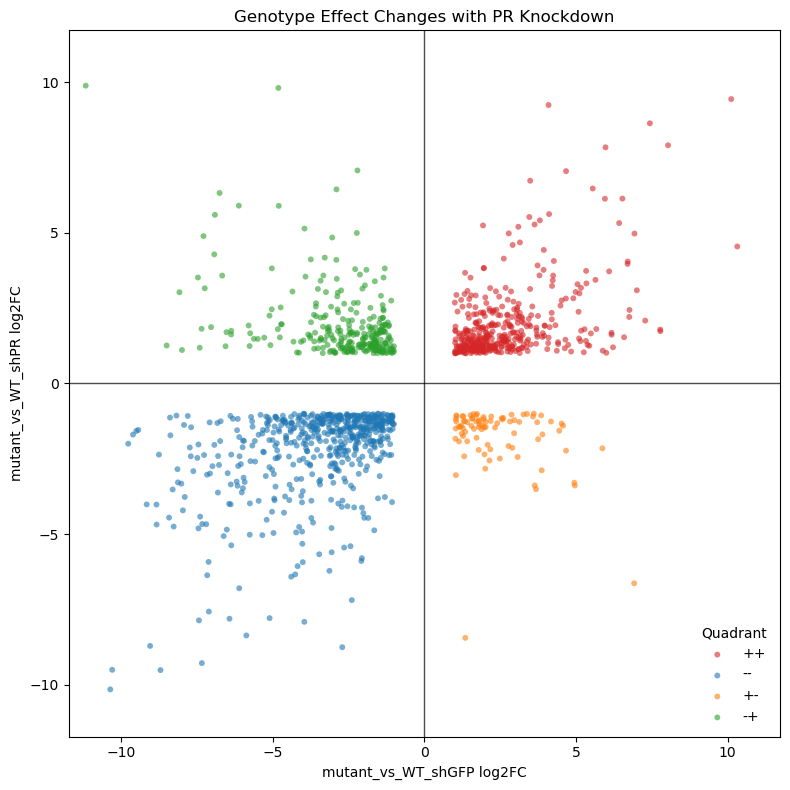

In [22]:
fig, ax, merged = plot_quadrant_scatter(
    df_x=df1,
    df_y=df2,
    label_x="mutant_vs_WT_shGFP",
    label_y="mutant_vs_WT_shPR",
    padj_thresh=0.05,
    lfc_thresh=1.0,
    title="Genotype Effect Changes with PR Knockdown",
)
plt.show()

**The Massive Reversal Effect (Green & Orange):** 

- The high density of genes in the Top-Left (Green) and Bottom-Right (Orange) quadrants shows that knocking down PR completely flips the behavior of mutant cells.

- **Orange (+-):** These are genes turned ON by the mutation at baseline, but over-corrected/crashed far below wild-type levels once PR is removed.
- **Green (-+):** These are genes suppressed (OFF) by the mutation at baseline, but hyper-activated far above wild-type levels post-knockdown.

**The Treatment-Resistant Genes (Red & Blue):** 

- Genes in the Top-Right (Red) and Bottom-Left (Blue) represent pathways where the mutation remains dominant. Despite knocking down PR, these genes remain abnormally elevated or suppressed in the mutant cells.

### Does treatment effect differ between WT and mutant?

(2872, 8)
(7441, 8)


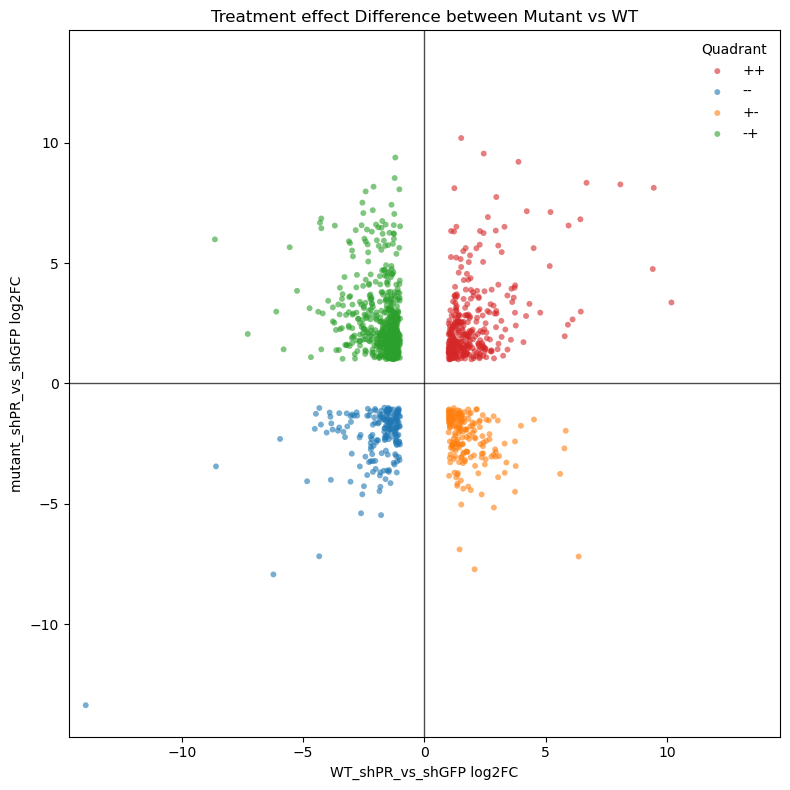

In [23]:
df1 = pd.read_csv("./deseq2_fit/deseq2_results/WT_shPR_vs_shGFP.significant.csv", index_col= 'gene_id')
df2 = pd.read_csv("./deseq2_fit/deseq2_results/mutant_shPR_vs_shGFP.significant.csv", index_col= 'gene_id')

print(df1.shape)
print(df2.shape)

fig, ax, merged = plot_quadrant_scatter(
    df_x=df1,
    df_y=df2,
    label_x="WT_shPR_vs_shGFP",
    label_y="mutant_shPR_vs_shGFP",
    padj_thresh=0.05,
    lfc_thresh=1.0,
    title="Treatment effect Difference between Mutant vs WT",
)
plt.show()

## Create Venn Diagram of DEGs

In [24]:
# Load metadata spreadsheet assuming 'sample_id' is either a column or the index
meta_df = pd.read_csv("sample_metadata.csv")
if 'sample_id' in meta_df.columns:
    meta_df = meta_df.set_index('sample_id')

# Create a clean mapping dictionary: {Sample_ID: Group_Label}
# (This maps SRR...71 to 'Y537S_shPR', SRR...74 to 'Y537S_shGFP', etc.)
sample_groups = meta_df['group'].to_dict()

# Grab active scaled heatmap matrix or already Z-score normalized expression matrix
# (Rows = 50 Ensembl IDs, Columns = 10 Sample IDs)
df_venn_matrix = df_expression_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# Aggregate individual samples by their metadata group and calculate the average Z-score
group_expr = df_venn_matrix.groupby(sample_groups, axis=1).mean()

# Define "Active Genes" as genes with an average expression Z-score > 0
# This mathematically separates upper heatmap blocks from lower blocks!
genes_mutant_ctrl = set(group_expr[group_expr['Y537S_shGFP'] > 0].index)
genes_mutant_shpr = set(group_expr[group_expr['Y537S_shPR'] > 0].index)
genes_wt_shpr     = set(group_expr[group_expr['WT_shPR'] > 0].index)


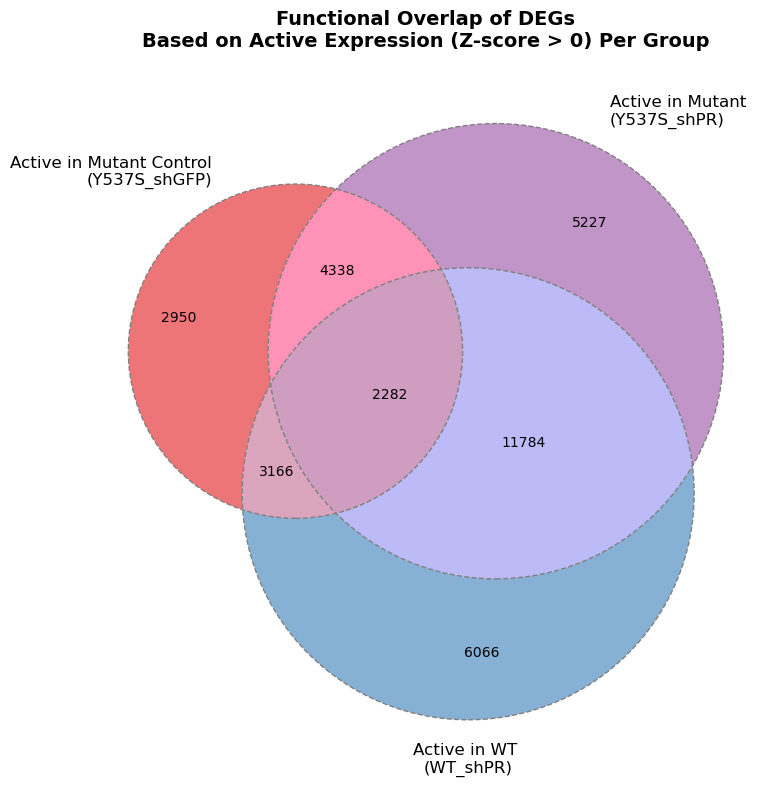

In [25]:
# Create Venn Diagram
plt.figure(figsize=(10, 8))
v = venn3(
    [genes_mutant_ctrl, genes_mutant_shpr, genes_wt_shpr],
    set_labels=(
        'Active in Mutant Control\n(Y537S_shGFP)', 
        'Active in Mutant \n(Y537S_shPR)', 
        'Active in WT \n(WT_shPR)'
    ),
    set_colors=('#e41a1c', '#984ea3', '#377eb8'),  # Red, Purple, Blue matching your heatmap tracks!
    alpha=0.6
)

# Overlay clean dashed borders around the circles
venn3_circles(
    [genes_mutant_ctrl, genes_mutant_shpr, genes_wt_shpr], 
    linestyle='--', 
    linewidth=1, 
    color='grey'
)

plt.title("Functional Overlap of DEGs\nBased on Active Expression (Z-score > 0) Per Group", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()